Steam Games Data Analysis (2025)
Data Analytics and Visualization Project

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set(style="whitegrid")
print("hello")
df = pd.read_csv("games_march2025_cleaned.csv")

# ===== REQUIRED TRANSFORMATIONS =====
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year
df['is_free'] = df['price'] == 0

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set(style="whitegrid")

df = pd.read_csv("games_march2025_cleaned.csv")

# Fix genres column
def safe_convert(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    elif isinstance(x, list):
        return x
    else:
        return []

df['genres'] = df['genres'].apply(safe_convert)

print("Data loaded and cleaned successfully")

Data loaded and cleaned successfully


Analysis 1: What is the distribution of game prices on Steam?

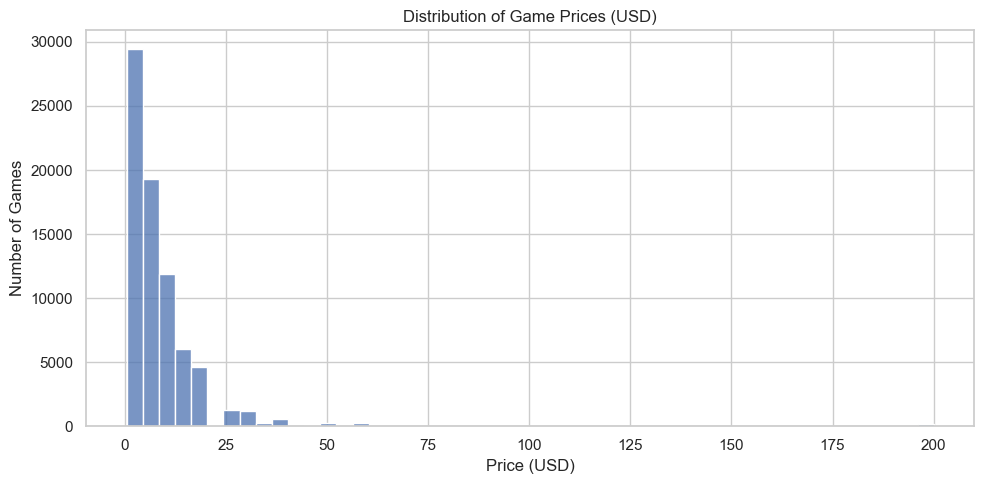

In [ ]:
price_df = df[(df['price'] > 0) & (df['price'] < 200)]

plt.figure(figsize=(10,5))

sns.histplot(price_df['price'], bins=50)
plt.title("Distribution of Game Prices (USD)")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

Conclusion:
The price distribution is highly skewed toward lower values, with most games priced below $20. This indicates that the Steam marketplace is dominated by affordable games, while high-priced titles are relatively rare.

Analysis 2: What is the distribution of game prices on Steam?

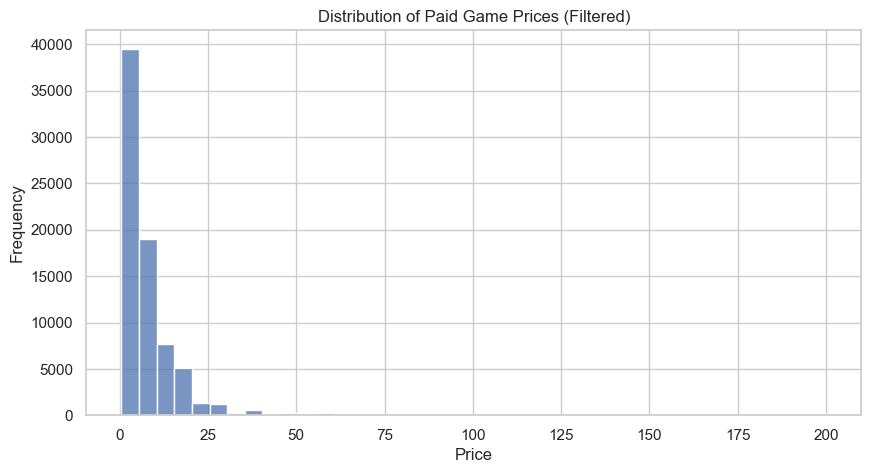

In [ ]:
plt.figure(figsize=(10,5))

filtered_df = df[(df['price'] > 0) & (df['price'] < 200)]

sns.histplot(filtered_df['price'], bins=40)

plt.title("Distribution of Paid Game Prices (Filtered)")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

Conclusion:
Most paid games on Steam are priced in the lower range, typically below 50. The dataset is highly skewed due to a large number of low-cost games and a few high-priced outliers.


Analysis 3: Which are the most common game genres on Steam?

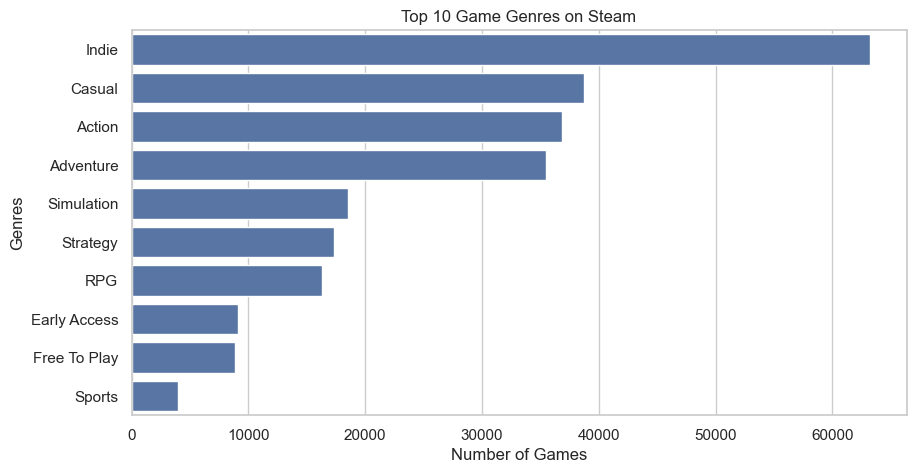

In [ ]:

all_genres = []

for sublist in df['genres']:
    if isinstance(sublist, list):   # safety check
        for genre in sublist:
            all_genres.append(genre.strip())

# Count top 10
genre_counts = pd.Series(all_genres).value_counts().head(10)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(x=genre_counts.values, y=genre_counts.index)

plt.title("Top 10 Game Genres on Steam")
plt.xlabel("Number of Games")
plt.ylabel("Genres")

plt.show()

Conclusion:
Most paid games on Steam are priced in the lower range, typically below 50. The dataset is highly skewed due to a large number of low-cost games and a few high-priced outliers.

Analysis 4: Which games have the highest number of positive reviews?

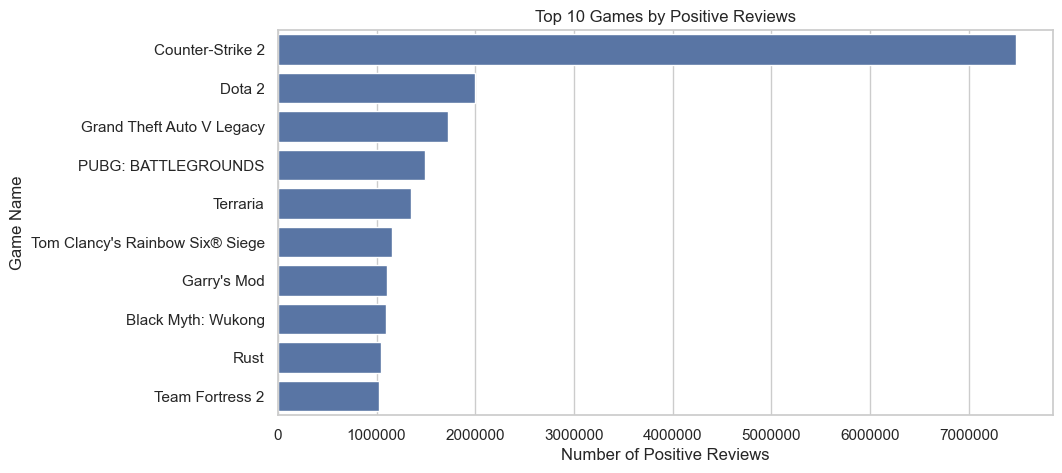

In [ ]:
top_games = df.sort_values(by='positive', ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_games['positive'], y=top_games['name'])

plt.title("Top 10 Games by Positive Reviews")
plt.xlabel("Number of Positive Reviews")
plt.ylabel("Game Name")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

Conclusion:
Popular and long-standing multiplayer games like Counter-Strike 2 and Dota 2 have the highest number of positive reviews, indicating strong user engagement and large player bases over time.


Analysis 5: What is the relationship between price and number of positive reviews (density view)?

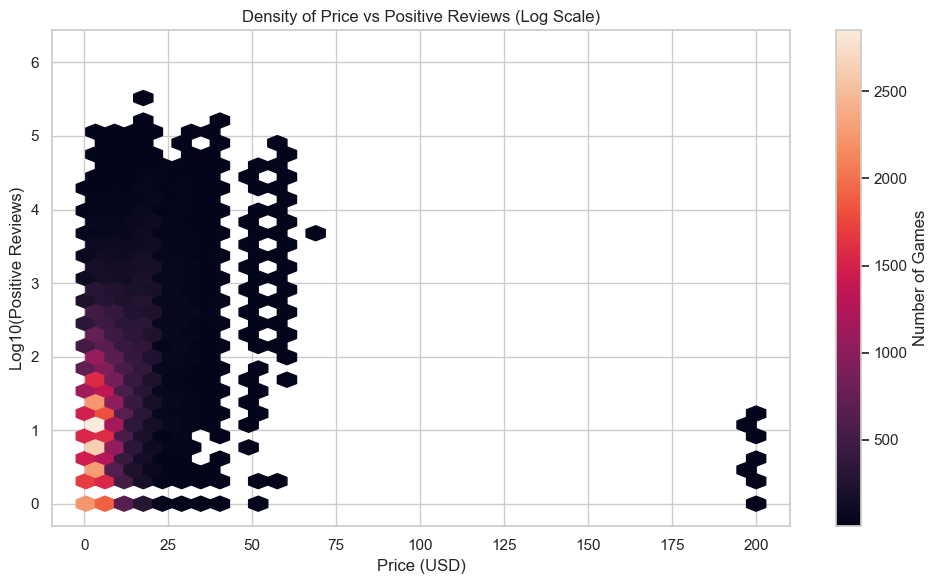

In [ ]:
plt.figure(figsize=(10,6))

hb = plt.hexbin(
    filtered_df['price'],
    filtered_df['log_positive'],
    gridsize=35,
    mincnt=5   # removes noise / empty bins
)

plt.title("Density of Price vs Positive Reviews (Log Scale)")
plt.xlabel("Price (USD)")
plt.ylabel("Log10(Positive Reviews)")

cb = plt.colorbar(hb)
cb.set_label('Number of Games')

plt.tight_layout()
plt.show()

Conclusion:
The density plot shows that the majority of games cluster at low prices and low-to-moderate review counts. High-review games are concentrated in the low-price range, while higher-priced games appear less frequently and attract fewer players, indicating that accessibility plays a stronger role than pricing in engagement.

Analysis 6: How do free and paid games compare in terms of number of games?

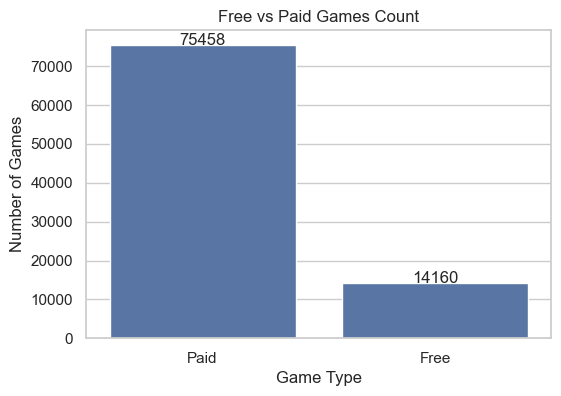

In [ ]:
# Create free vs paid column
df['is_free'] = df['price'].apply(lambda x: 'Free' if x == 0 else 'Paid')

# Count
counts = df['is_free'].value_counts()

plt.figure(figsize=(6,4))

sns.barplot(x=counts.index, y=counts.values)

# 👉 ADD HERE
for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha='center')

plt.title("Free vs Paid Games Count")
plt.xlabel("Game Type")
plt.ylabel("Number of Games")

plt.show()


Conclusion:
The number of paid games is higher than free games on Steam. However, free games still form a significant portion of the dataset, reflecting the popularity of the free-to-play model.

Analysis 7: What is the distribution of average playtime among games?

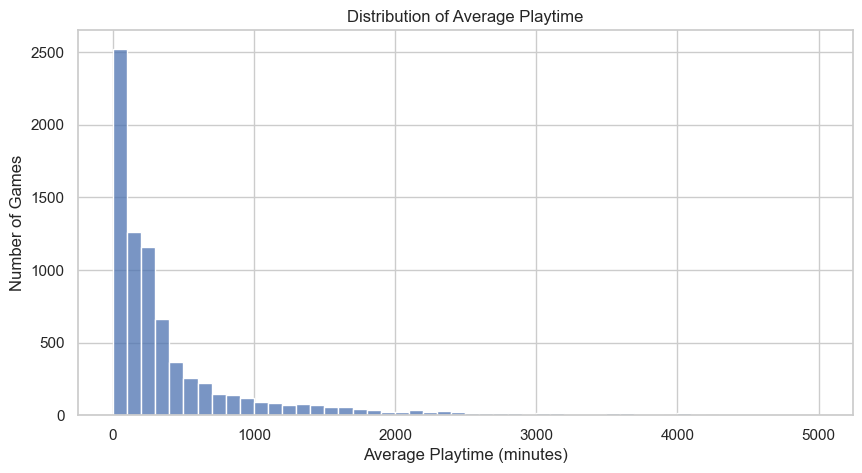

In [ ]:
# Filter realistic playtime range
playtime_df = df[(df['average_playtime_forever'] > 0) & (df['average_playtime_forever'] < 5000)]

plt.figure(figsize=(10,5))

sns.histplot(playtime_df['average_playtime_forever'], bins=50)

plt.title("Distribution of Average Playtime")
plt.xlabel("Average Playtime (minutes)")
plt.ylabel("Number of Games")

plt.show()

Conclusion:
Most games have low average playtime, while a small number of games have very high playtime, indicating that only a few games maintain long-term player engagement.

Analysis 8: How does peak concurrent users (peak_ccu) vary across games?

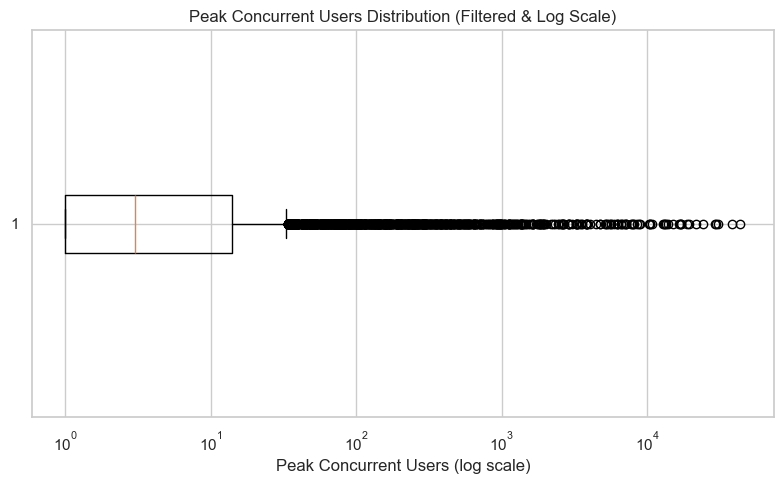

In [ ]:
# Clean and filter data properly
ccu_df = df[(df['peak_ccu'] > 0) & (df['peak_ccu'] < 50000)]

# Optional: sample to reduce heavy dataset load
ccu_sample = ccu_df['peak_ccu'].sample(5000, random_state=42)

plt.figure(figsize=(8,5))

plt.boxplot(ccu_sample, vert=False)

plt.xscale('log')

plt.title("Peak Concurrent Users Distribution (Filtered & Log Scale)")
plt.xlabel("Peak Concurrent Users (log scale)")

plt.tight_layout()
plt.show()

Conclusion:
The distribution of peak concurrent users is highly skewed, with most games having very low player counts and a few games achieving extremely high concurrency. This indicates that player engagement is concentrated among a small number of highly popular games.

Analysis 9: What is the distribution of positive review percentage (pct_pos_total)?

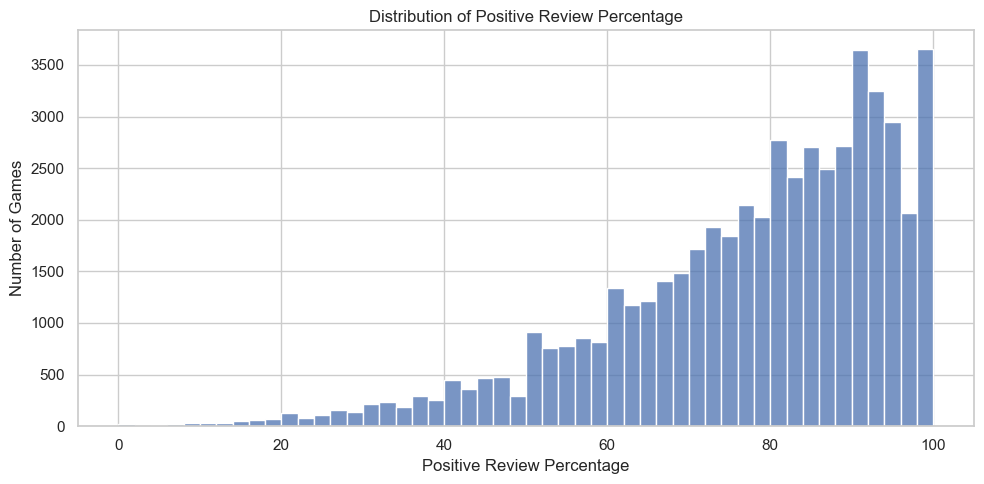

In [ ]:
# Filter valid percentage values
pct_df = df[(df['pct_pos_total'] >= 0) & (df['pct_pos_total'] <= 100)]

plt.figure(figsize=(10,5))

sns.histplot(pct_df['pct_pos_total'], bins=50)

plt.title("Distribution of Positive Review Percentage")
plt.xlabel("Positive Review Percentage")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

Conclusion:
Most games have a high percentage of positive reviews, indicating that user feedback on Steam is generally favorable, with many games receiving more positive than negative responses.

Analysis 10: How has the number of games released changed over time?

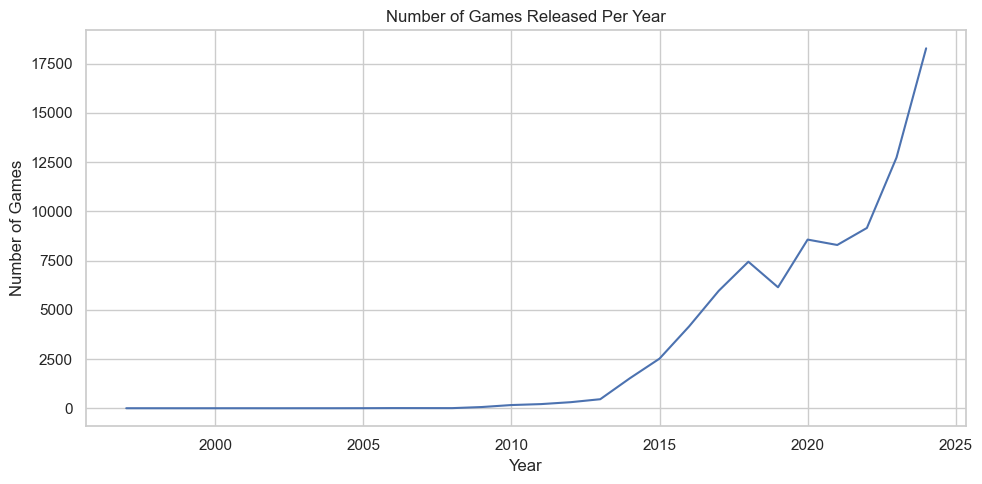

In [ ]:
year_counts = df['year'].value_counts().sort_index()

# Remove incomplete latest year
year_counts = year_counts[year_counts.index < 2025]

plt.figure(figsize=(10,5))

sns.lineplot(x=year_counts.index, y=year_counts.values)

plt.title("Number of Games Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

Conclusion:
The number of games released on Steam has increased significantly over time, especially after 2015, indicating rapid growth in the gaming industry. The apparent drop in the latest year is due to incomplete data and does not represent an actual decline.

Analysis 11: How does average playtime vary with game price?

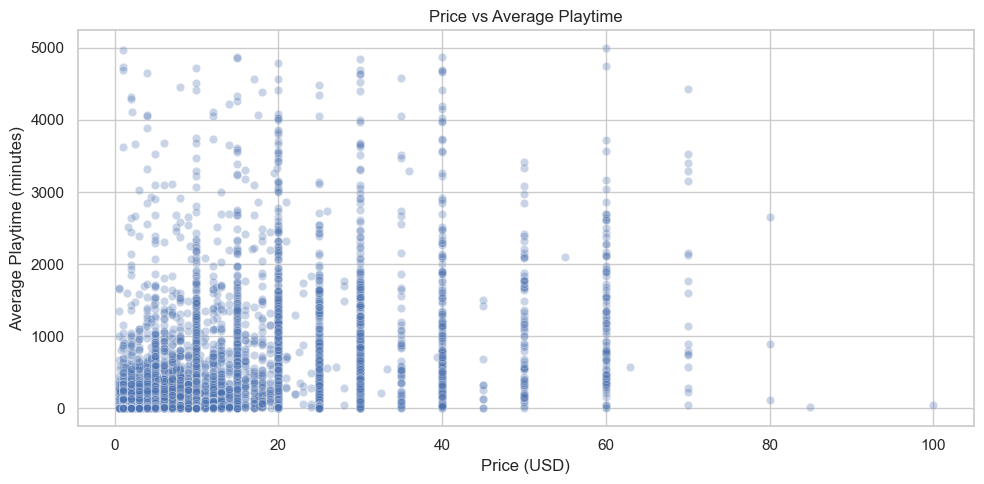

In [ ]:
play_df = df[(df['price'] > 0) & (df['price'] < 100) &
             (df['average_playtime_forever'] > 0) & (df['average_playtime_forever'] < 5000)]

plt.figure(figsize=(10,5))

sns.scatterplot(x=play_df['price'], y=play_df['average_playtime_forever'], alpha=0.3)

plt.title("Price vs Average Playtime")
plt.xlabel("Price (USD)")
plt.ylabel("Average Playtime (minutes)")

plt.tight_layout()
plt.show()

Conclusion:
There is no clear relationship between price and average playtime. High engagement is observed across various price ranges, indicating that gameplay quality and design have a greater impact on player retention than pricing.


Analysis 12: How does positive review percentage relate to average playtime?

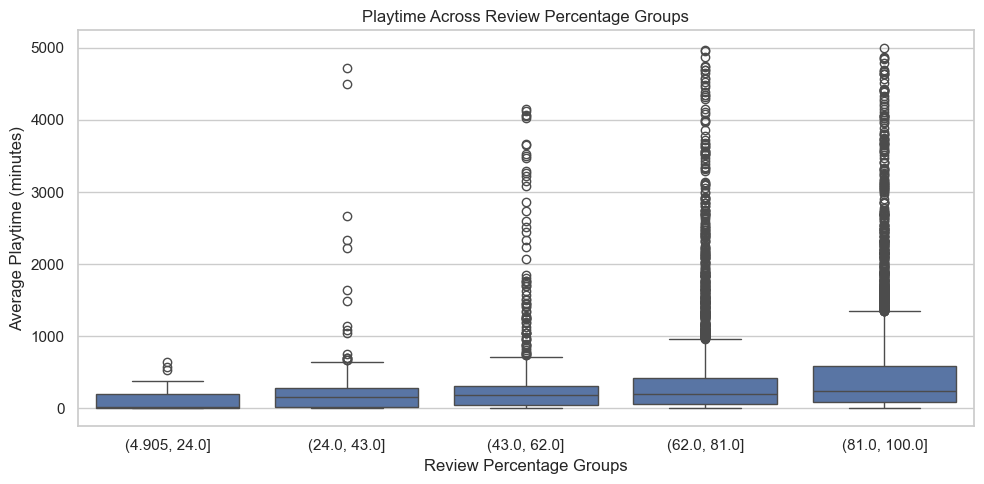

In [ ]:
review_play_df = df[(df['pct_pos_total'] >= 0) & (df['pct_pos_total'] <= 100) &
                    (df['average_playtime_forever'] > 0) & (df['average_playtime_forever'] < 5000)]

plt.figure(figsize=(10,5))

sns.boxplot(x=pd.cut(review_play_df['pct_pos_total'], bins=5),
            y=review_play_df['average_playtime_forever'])

plt.title("Playtime Across Review Percentage Groups")
plt.xlabel("Review Percentage Groups")
plt.ylabel("Average Playtime (minutes)")

plt.tight_layout()
plt.show()

Conclusion:
Games with higher review percentages tend to have higher median playtime, indicating that better-rated games generally retain players for longer durations.

Analysis 13: Which game genres have the highest average playtime?

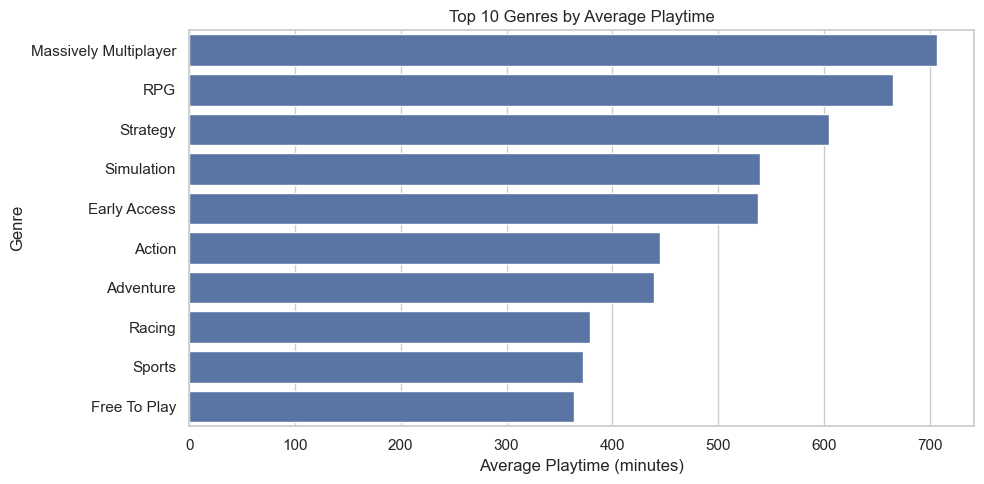

In [ ]:
# Clean genres properly
import ast

def safe_convert(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    elif isinstance(x, list):
        return x
    else:
        return []

df['genres_clean'] = df['genres'].apply(safe_convert)

# Explode genres
genre_df = df.explode('genres_clean')
exclude_genres = [
    'Web Publishing',
    'Audio Production',
    'Utilities',
    'Video Production'
]

genre_df = genre_df[~genre_df['genres_clean'].isin(exclude_genres)]
# Filter valid playtime
genre_df = genre_df[(genre_df['average_playtime_forever'] > 0) &
                    (genre_df['average_playtime_forever'] < 5000)]

# Group by genre
genre_playtime = genre_df.groupby('genres_clean')['average_playtime_forever'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=genre_playtime.values, y=genre_playtime.index)

plt.title("Top 10 Genres by Average Playtime")
plt.xlabel("Average Playtime (minutes)")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

Conclusion:
Certain genres show significantly higher average playtime, indicating that genre plays a crucial role in player engagement and retention. Genres focused on strategy, simulation, or long-term progression tend to have higher playtime.

Analysis 14: Which developers have the highest number of games on Steam?

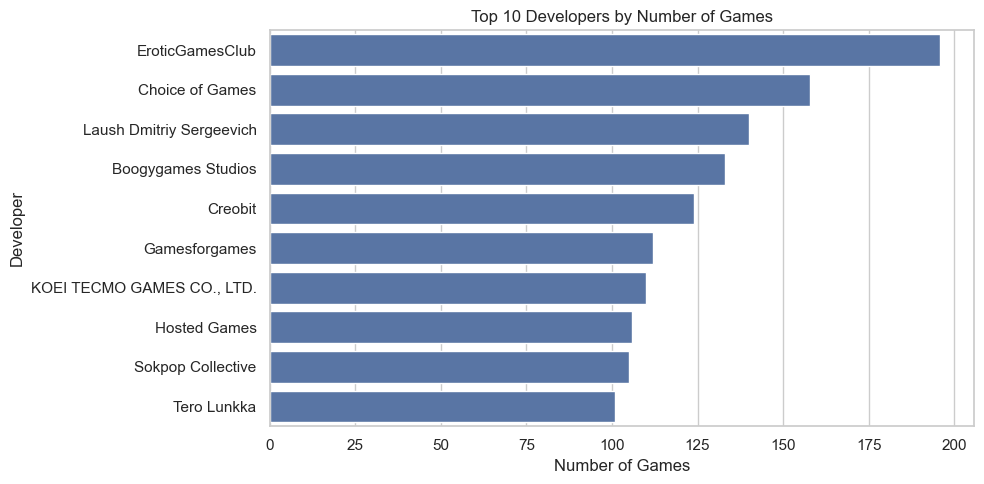

In [ ]:
import ast

# Clean developers column
def safe_convert(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    elif isinstance(x, list):
        return x
    else:
        return []

df['developers_clean'] = df['developers'].apply(safe_convert)

# Explode
dev_df = df.explode('developers_clean')

# Count properly
dev_counts = dev_df['developers_clean'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=dev_counts.values, y=dev_counts.index)

plt.title("Top 10 Developers by Number of Games")
plt.xlabel("Number of Games")
plt.ylabel("Developer")

plt.tight_layout()
plt.show()

Conclusion:
The analysis shows that some developers release a large number of games on Steam, often smaller or niche titles. This indicates that high game count does not necessarily reflect popularity or impact, but rather publishing frequency.

Analysis 15: Which developers have the highest total positive reviews?

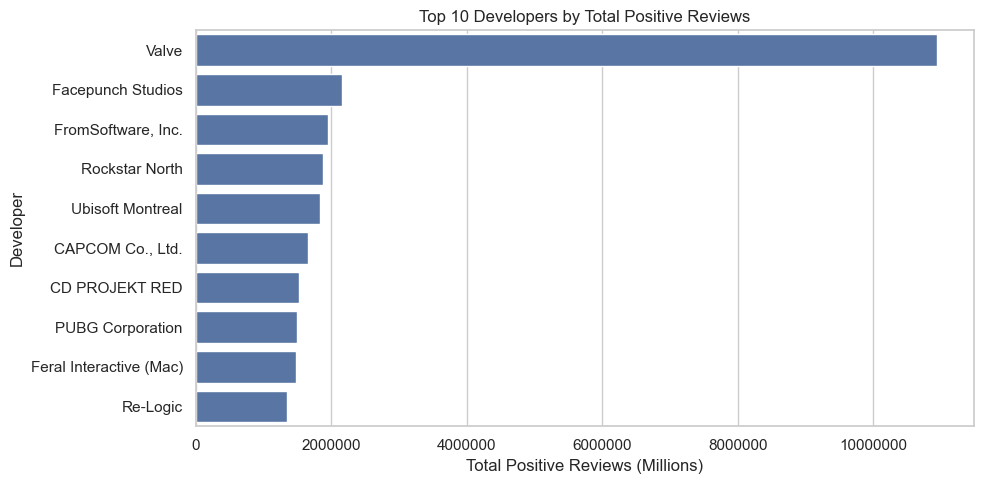

In [ ]:
# Use already cleaned developers_clean

# Group by developer and sum positive reviews
dev_reviews = dev_df.groupby('developers_clean')['positive'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=dev_reviews.values, y=dev_reviews.index)

plt.title("Top 10 Developers by Total Positive Reviews")
plt.xlabel("Total Positive Reviews (Millions)")
plt.ylabel("Developer")
plt.ticklabel_format(style='plain', axis='x')
plt.tight_layout()
plt.show()

Analysis 16: Which publishers have the highest total positive reviews?

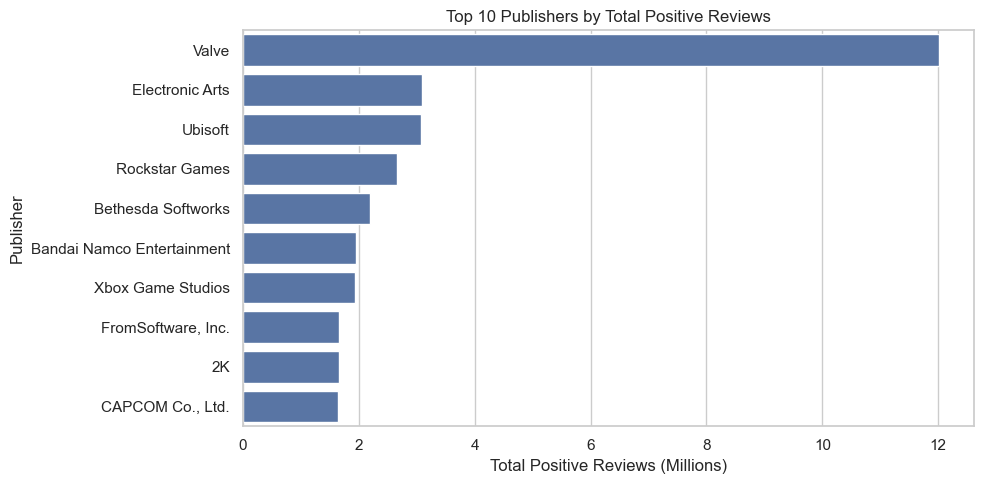

In [ ]:
import ast

# Clean publishers column
def safe_convert(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    elif isinstance(x, list):
        return x
    else:
        return []

df['publishers_clean'] = df['publishers'].apply(safe_convert)

# Explode
pub_df = df.explode('publishers_clean')

# Group and sum
pub_reviews = pub_df.groupby('publishers_clean')['positive'].sum().sort_values(ascending=False).head(10)

# Convert to millions for readability
pub_reviews = pub_reviews / 1_000_000

plt.figure(figsize=(10,5))

sns.barplot(x=pub_reviews.values, y=pub_reviews.index)

plt.title("Top 10 Publishers by Total Positive Reviews")
plt.xlabel("Total Positive Reviews (Millions)")
plt.ylabel("Publisher")

plt.tight_layout()
plt.show()

Conclusion:
A few publishers dominate total positive reviews, indicating that major publishing companies play a key role in distributing highly successful and widely played games.

Analysis 17: What are the relationships between key numerical features?

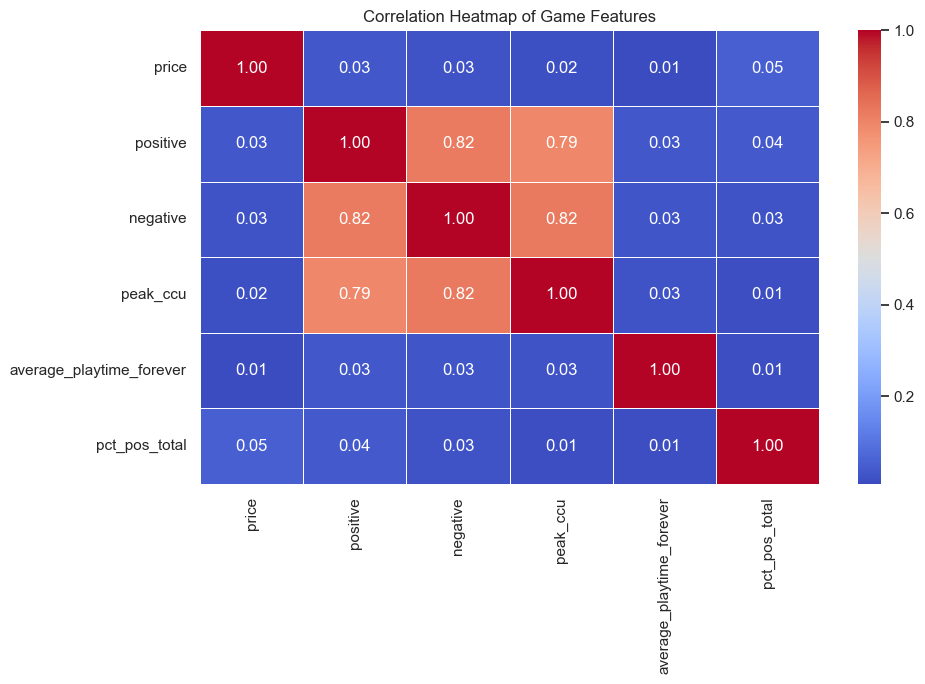

In [ ]:
import seaborn as sns

# Select relevant numeric columns
corr_df = df[['price', 'positive', 'negative', 'peak_ccu',
              'average_playtime_forever', 'pct_pos_total']].dropna()

# Correlation
corr_matrix = corr_df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Game Features")

plt.tight_layout()
plt.show()

Conclusion:
The correlation heatmap shows a strong positive relationship between positive reviews and peak concurrent users, indicating that highly popular games attract more players. Price has little to no correlation with engagement metrics, suggesting that popularity depends more on game quality and reach than pricing.

Analysis 18: How does average playtime vary across different price ranges?

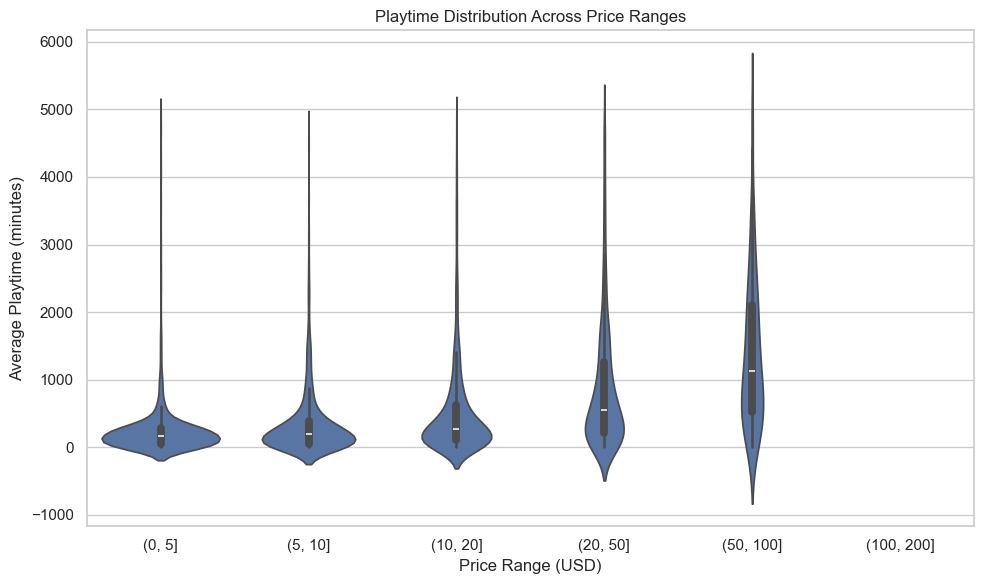

In [ ]:
import seaborn as sns

# Create price bins
df['price_group'] = pd.cut(df['price'], bins=[0,5,10,20,50,100,200])

# Filter valid playtime
play_df = df[(df['average_playtime_forever'] > 0) &
             (df['average_playtime_forever'] < 5000)]

plt.figure(figsize=(10,6))

sns.violinplot(
    x=play_df['price_group'],
    y=play_df['average_playtime_forever']
)

plt.title("Playtime Distribution Across Price Ranges")
plt.xlabel("Price Range (USD)")
plt.ylabel("Average Playtime (minutes)")

plt.tight_layout()
plt.show()

Conclusion:
The violin plot shows that lower-priced games have a wider spread of playtime, including some highly engaging titles. Higher-priced games tend to have more consistent but not necessarily higher playtime, indicating that price does not directly determine engagement.

Analysis 19: What is the distribution of positive review percentages?

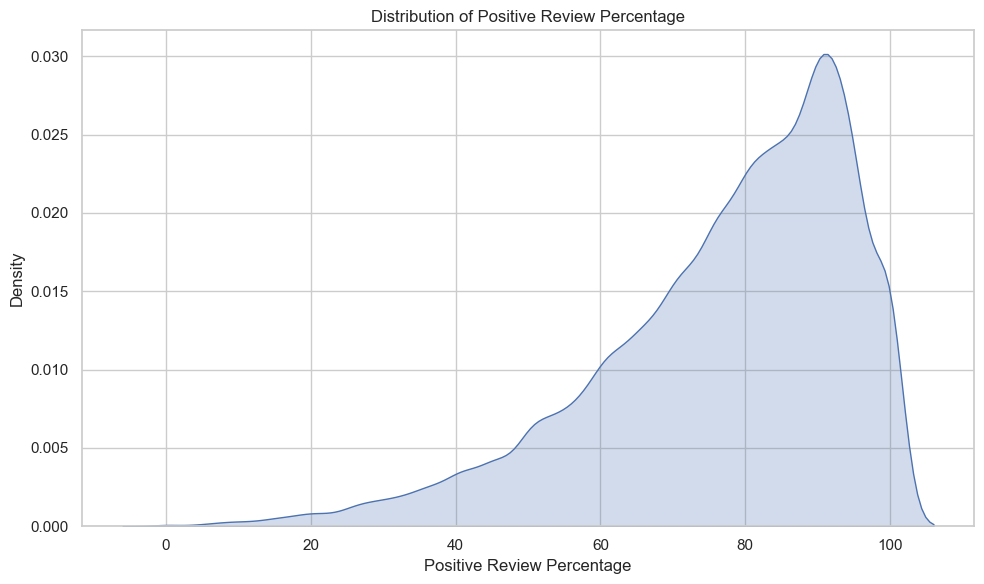

In [ ]:
import seaborn as sns

# Filter valid percentage values
review_df = df[(df['pct_pos_total'] >= 0) & (df['pct_pos_total'] <= 100)]

plt.figure(figsize=(10,6))

sns.kdeplot(review_df['pct_pos_total'], fill=True)

plt.title("Distribution of Positive Review Percentage")
plt.xlabel("Positive Review Percentage")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

Conclusion:
The KDE plot shows that most games have high positive review percentages, with a strong concentration above 70%. This indicates that the majority of games on Steam receive generally favorable feedback from players.

Analysis 20: How does average positive review percentage vary across price ranges?

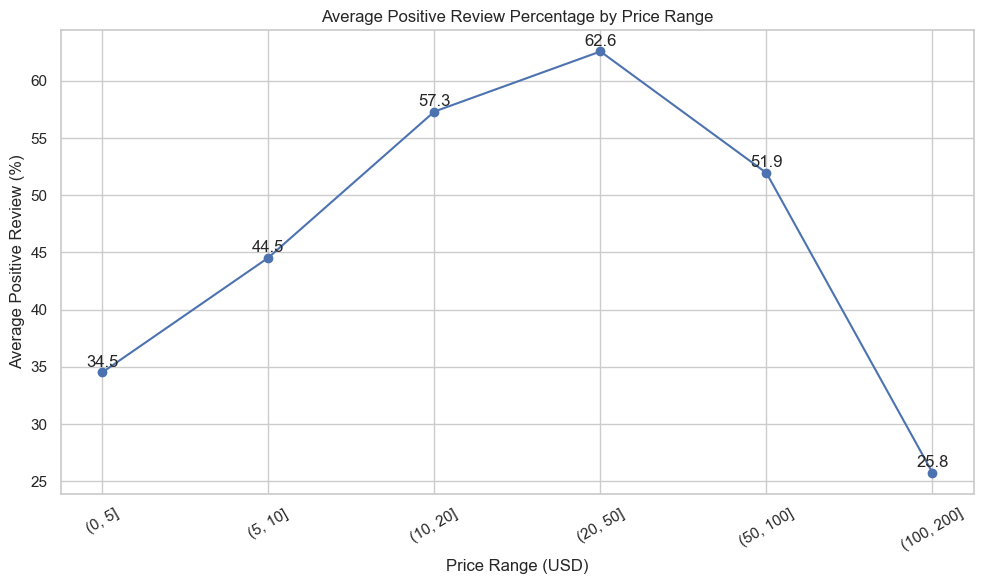

In [ ]:
plt.figure(figsize=(10,6))

x_vals = group_df.index.astype(str)
y_vals = group_df.values

plt.plot(x_vals, y_vals, marker='o')

# Add labels on points
for i, v in enumerate(y_vals):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center')

plt.title("Average Positive Review Percentage by Price Range")
plt.xlabel("Price Range (USD)")
plt.ylabel("Average Positive Review (%)")

plt.xticks(rotation=30)
plt.grid(True)

plt.tight_layout()
plt.show()

Conclusion:
The trend shows that review percentages increase from low to mid-price ranges, peaking around moderately priced games, and then decline for higher-priced games. This suggests that mid-priced games tend to balance quality and accessibility more effectively.

Analysis 21: What is the proportion of free vs paid games on Steam?

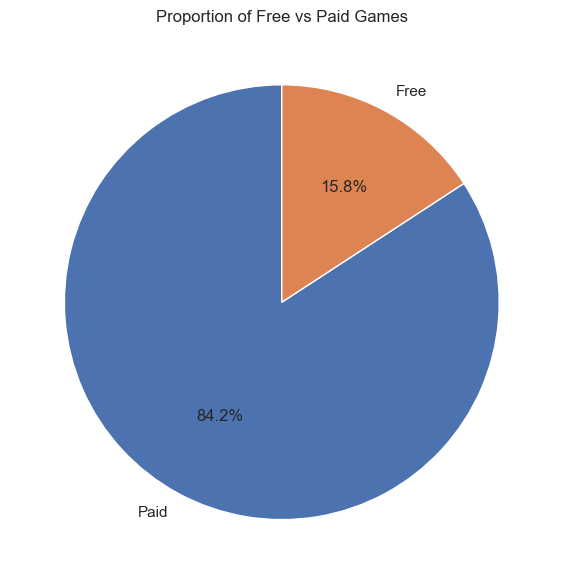

In [ ]:
# Create is_free column manually
df['is_free'] = df['price'] == 0

# Count free vs paid
counts = df['is_free'].value_counts()

labels = ['Paid', 'Free']
values = [counts.get(False, 0), counts.get(True, 0)]

plt.figure(figsize=(6,6))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Proportion of Free vs Paid Games")

plt.tight_layout()
plt.show()

Conclusion:
The majority of games on Steam are paid, while free-to-play games form a smaller portion of the platform. This indicates that the marketplace is still largely driven by paid content, although free games play a significant role in attracting large player bases.

Analysis 22: How do free and paid games differ across release years?

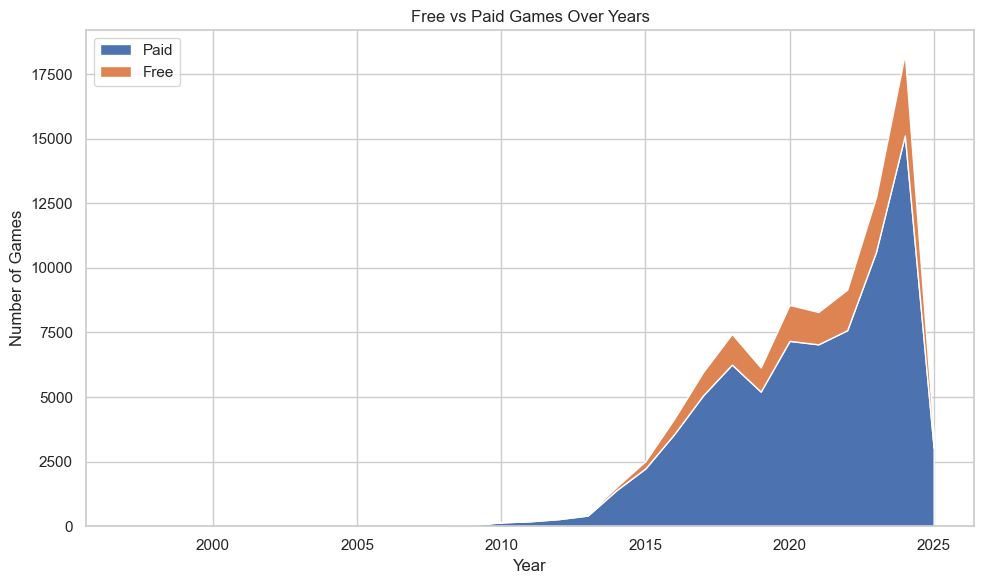

In [ ]:
# Ensure is_free exists
df['is_free'] = df['price'] == 0

# Group data
year_free = df.groupby(['year', 'is_free']).size().unstack().fillna(0)

plt.figure(figsize=(10,6))

plt.stackplot(
    year_free.index,
    year_free[False],
    year_free[True],
    labels=['Paid', 'Free']
)

plt.title("Free vs Paid Games Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.legend()

plt.tight_layout()
plt.show()

Conclusion:
The number of both free and paid games has increased over time, with paid games consistently dominating the platform. Free-to-play games show gradual growth, indicating their rising role in attracting larger audiences.


Analysis 23: What is the distribution of positive reviews after applying logarithmic scaling?

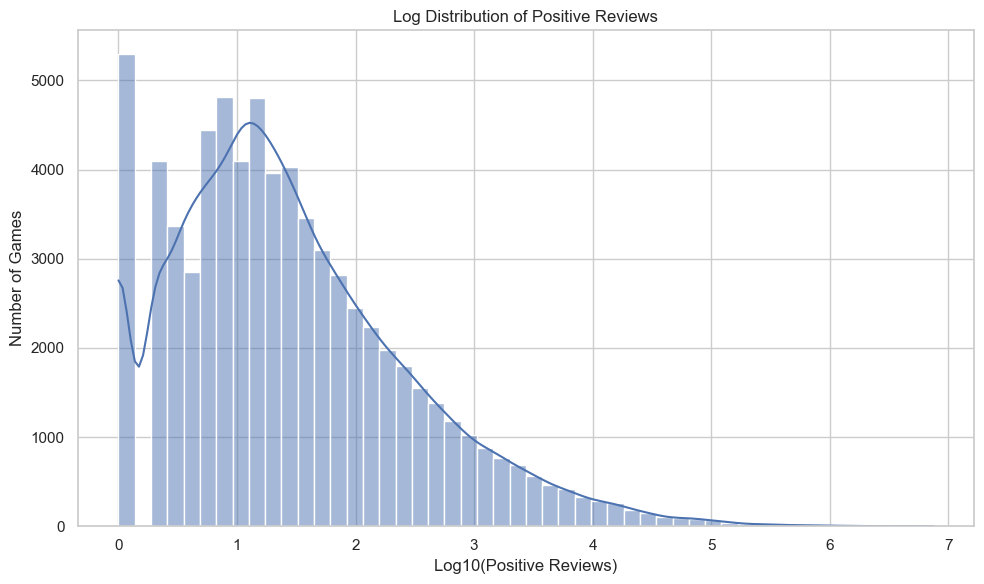

In [ ]:
import numpy as np

# Filter valid values
pos_df = df[df['positive'] > 0].copy()

# Log transform
pos_df['log_positive'] = np.log10(pos_df['positive'])

plt.figure(figsize=(10,6))

sns.histplot(pos_df['log_positive'], bins=50, kde=True)

plt.title("Log Distribution of Positive Reviews")
plt.xlabel("Log10(Positive Reviews)")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

Conclusion:
After applying logarithmic scaling, the distribution of positive reviews reveals a long-tail pattern where most games receive relatively few reviews, while a small number of games achieve extremely high popularity.

Analysis 24: How are positive reviews distributed cumulatively across games?

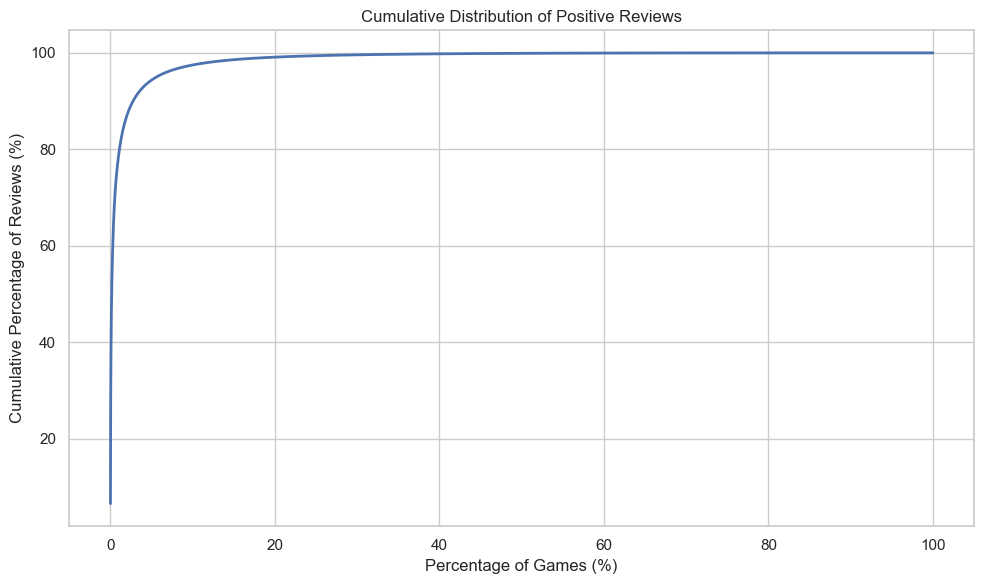

In [ ]:
sorted_df = df.sort_values(by='positive', ascending=False).reset_index(drop=True)

sorted_df['cum_reviews'] = sorted_df['positive'].cumsum()

total_reviews = sorted_df['positive'].sum()
sorted_df['cum_percent'] = sorted_df['cum_reviews'] / total_reviews * 100

# Correct rank
sorted_df['rank_percent'] = (sorted_df.index + 1) / len(sorted_df) * 100
plt.figure(figsize=(10,6))

plt.plot(sorted_df['rank_percent'], sorted_df['cum_percent'], linewidth=2)

plt.title("Cumulative Distribution of Positive Reviews")
plt.xlabel("Percentage of Games (%)")
plt.ylabel("Cumulative Percentage of Reviews (%)")

plt.grid(True)

plt.tight_layout()
plt.show()

Conclusion:
The cumulative distribution shows that a small percentage of games contribute to the majority of positive reviews. This indicates a highly unequal distribution where a few popular games dominate user engagement.

Analysis 25: How unequal is the distribution of positive reviews among games? (Lorenz Curve)

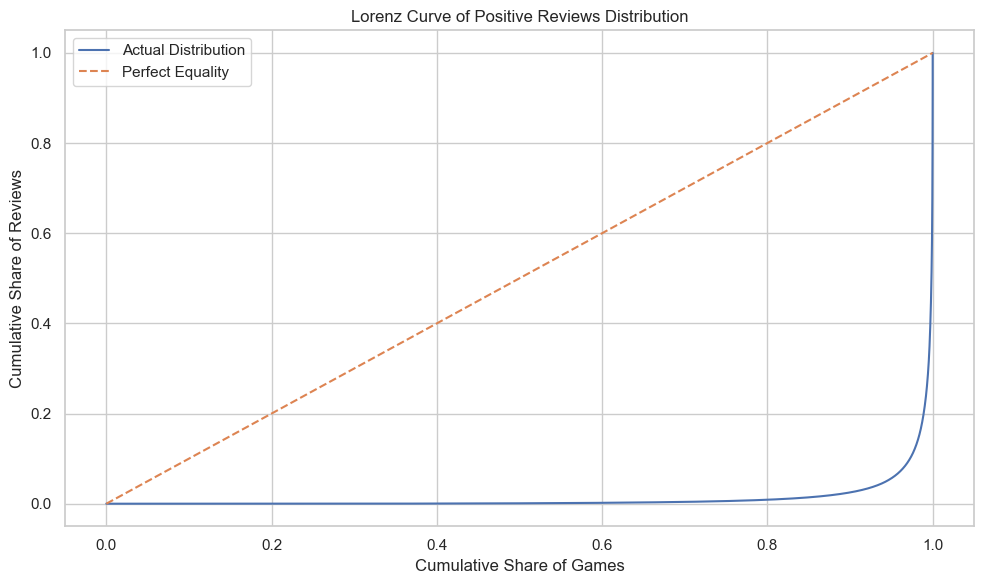

In [ ]:
# Sort data
lorenz_df = df.sort_values(by='positive').reset_index(drop=True)

# Cumulative share of reviews
lorenz_df['cum_reviews'] = lorenz_df['positive'].cumsum()
total_reviews = lorenz_df['positive'].sum()

lorenz_df['cum_reviews_pct'] = lorenz_df['cum_reviews'] / total_reviews

# Cumulative share of games
lorenz_df['cum_games_pct'] = (lorenz_df.index + 1) / len(lorenz_df)

plt.figure(figsize=(10,6))

# Lorenz curve
plt.plot(lorenz_df['cum_games_pct'], lorenz_df['cum_reviews_pct'], label='Actual Distribution')

# Perfect equality line
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Equality')

plt.title("Lorenz Curve of Positive Reviews Distribution")
plt.xlabel("Cumulative Share of Games")
plt.ylabel("Cumulative Share of Reviews")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Conclusion:
The Lorenz curve shows a strong deviation from perfect equality, indicating that positive reviews are highly concentrated among a small fraction of games. This confirms a highly unequal distribution of player engagement.

Analysis 26: What relationships exist between key numerical features?

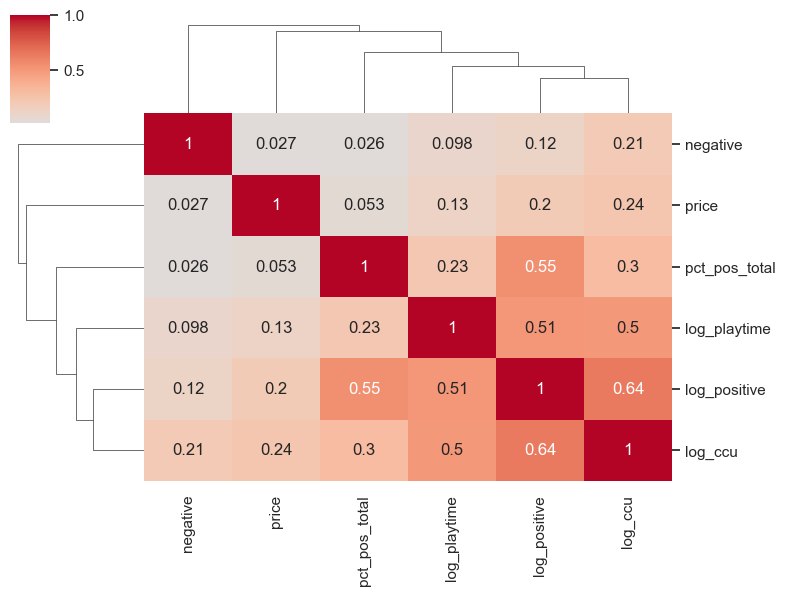

In [ ]:
import numpy as np

# Select relevant columns
corr_df = df[[
    'price',
    'positive',
    'negative',
    'peak_ccu',
    'average_playtime_forever',
    'pct_pos_total'
]].copy()

# Clean data
corr_df = corr_df.replace([np.inf, -np.inf], np.nan).dropna()

# Log transform skewed features
corr_df['log_positive'] = np.log1p(corr_df['positive'])
corr_df['log_ccu'] = np.log1p(corr_df['peak_ccu'])
corr_df['log_playtime'] = np.log1p(corr_df['average_playtime_forever'])

# Final features
final_corr = corr_df[[
    'price',
    'log_positive',
    'negative',
    'log_ccu',
    'log_playtime',
    'pct_pos_total'
]]

# Correlation
corr_matrix = final_corr.corr()

# CLUSTERED HEATMAP (key change)
sns.clustermap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    figsize=(8,6)
)

plt.show()

Conclusion:
The clustered heatmap reveals clear grouping among engagement-related variables such as peak concurrent users and positive reviews, indicating strong interdependence. Price remains weakly connected, suggesting that popularity is driven more by engagement factors than cost.

Analysis 27: How does playtime vary across different price categories?

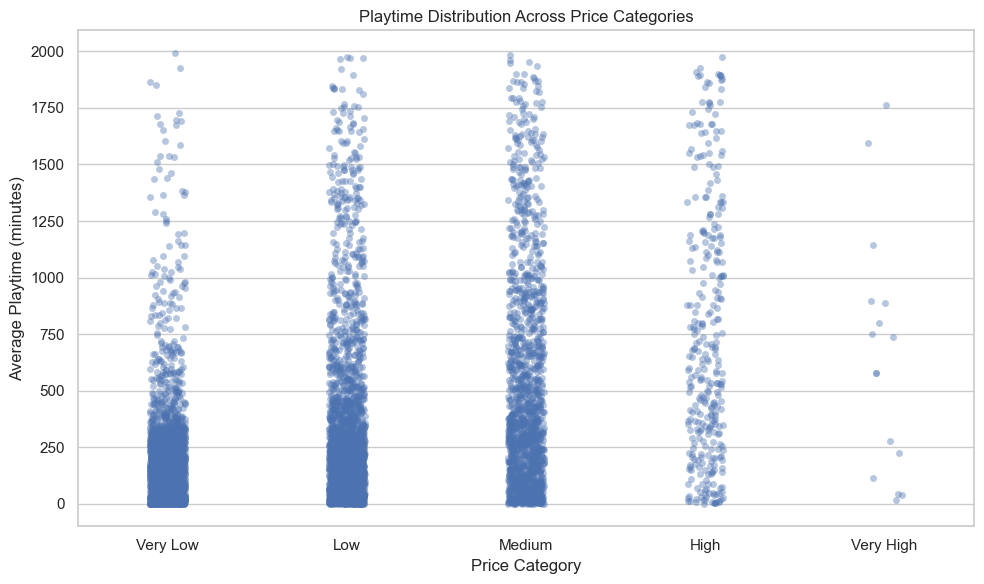

In [ ]:
# Create price categories
df['price_category'] = pd.cut(
    df['price'],
    bins=[0, 5, 15, 30, 60, 200],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Filter realistic values
strip_df = df[
    (df['average_playtime_forever'] > 0) &
    (df['average_playtime_forever'] < 2000)
].copy()

plt.figure(figsize=(10,6))

sns.stripplot(
    data=strip_df,
    x='price_category',
    y='average_playtime_forever',
    jitter=True,
    alpha=0.4
)

plt.title("Playtime Distribution Across Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Average Playtime (minutes)")

plt.tight_layout()
plt.show()

Conclusion:
Playtime varies significantly across all price categories, with no consistent increase in engagement as price rises. This suggests that higher pricing does not guarantee longer player engagement.

Analysis 28: How does playtime distribution change across price categories? (Ridgeline view)

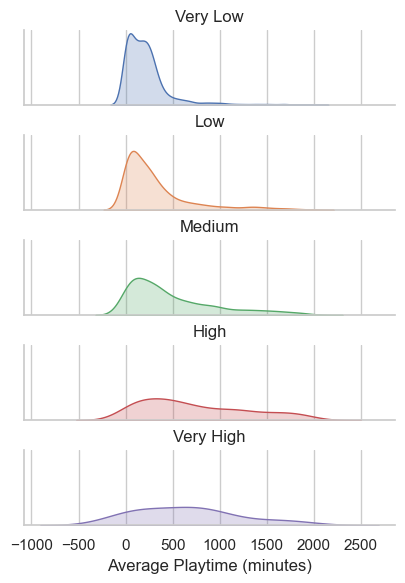

In [ ]:
# Filter data
ridge_df = df[
    (df['average_playtime_forever'] > 0) &
    (df['average_playtime_forever'] < 2000)
].copy()

# Ensure category order
ridge_df['price_category'] = pd.Categorical(
    ridge_df['price_category'],
    categories=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
    ordered=True
)

# Facet Grid (correct ridgeline-style)
g = sns.FacetGrid(
    ridge_df,
    row="price_category",
    hue="price_category",
    aspect=4,
    height=1.2,
    sharex=True
)

g.map(sns.kdeplot, "average_playtime_forever", fill=True)

g.set_titles(row_template="{row_name}")
g.set(yticks=[], ylabel="")

g.fig.subplots_adjust(hspace=0.4)

g.set_xlabels("Average Playtime (minutes)")

plt.show()

Conclusion:
The ridgeline plot shows that playtime distributions vary across price categories, but no category consistently dominates in engagement. Lower-priced games often have wider distributions, indicating both casual and highly engaged player bases.

Analysis 29: How does playtime distribution vary across top genres?

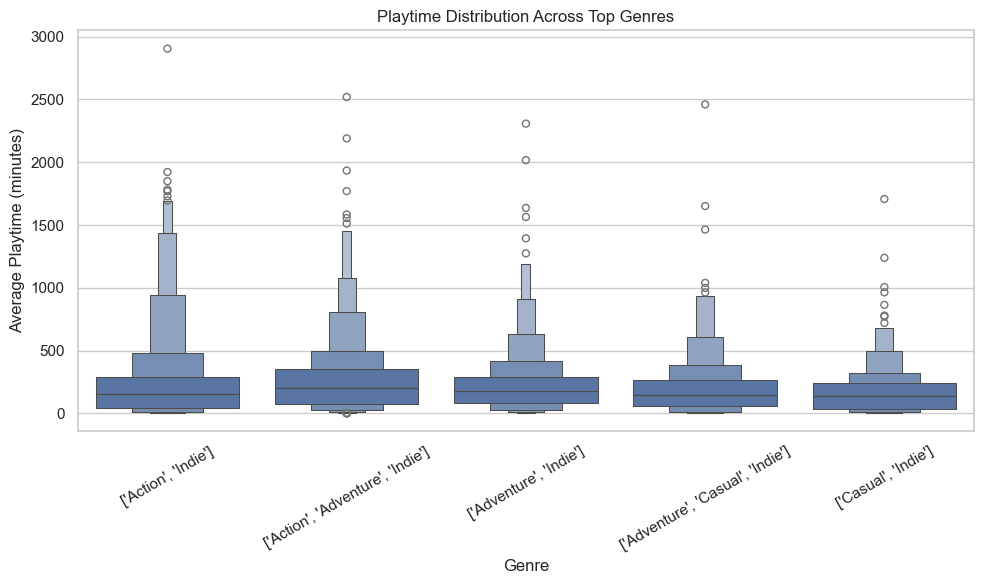

In [ ]:
# Ensure genres is list (you already did safe_convert earlier)

# Explode genres (IMPORTANT)
genre_exploded = df.explode('genres')

# Get top 5 genres
top_genres = genre_exploded['genres'].value_counts().head(5).index

# Filter for those genres
genre_df = genre_exploded[
    genre_exploded['genres'].isin(top_genres)
].copy()

# Rename for clarity
genre_df = genre_df.rename(columns={'genres': 'genre'})

# Filter valid playtime
genre_df = genre_df[
    (genre_df['average_playtime_forever'] > 0) &
    (genre_df['average_playtime_forever'] < 3000)
]

plt.figure(figsize=(10,6))

sns.boxenplot(
    data=genre_df,
    x='genre',
    y='average_playtime_forever'
)

plt.title("Playtime Distribution Across Top Genres")
plt.xlabel("Genre")
plt.ylabel("Average Playtime (minutes)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Conclusion:
Different genres show distinct playtime distributions, with some genres exhibiting wider variability and longer engagement tails. This suggests that player engagement patterns vary significantly depending on game genre.

Analysis 30: Where are games concentrated in terms of price and popularity?

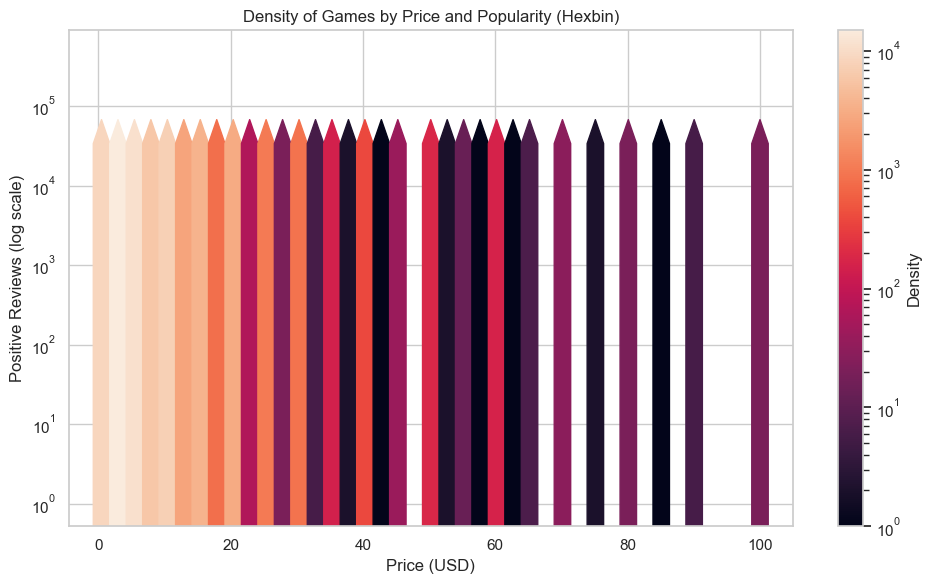

In [ ]:
# Filter realistic values
hex_df = df[
    (df['price'] > 0) &
    (df['price'] < 100) &
    (df['positive'] > 0)
].copy()

# Reduce skew
hex_df = hex_df[hex_df['positive'] < 500000]

plt.figure(figsize=(10,6))

plt.hexbin(
    hex_df['price'],
    hex_df['positive'],
    gridsize=40,
    bins='log'
)

plt.yscale('log')

plt.title("Density of Games by Price and Popularity (Hexbin)")
plt.xlabel("Price (USD)")
plt.ylabel("Positive Reviews (log scale)")

cb = plt.colorbar()
cb.set_label('Density')

plt.tight_layout()
plt.show()

Conclusion:
The density plot shows that most games are concentrated in lower price ranges with relatively low to moderate popularity. Highly popular games are fewer and spread across different price levels, indicating that success is not limited to a specific price range.

Analysis 31: Which are the top 10 most popular games based on positive reviews?

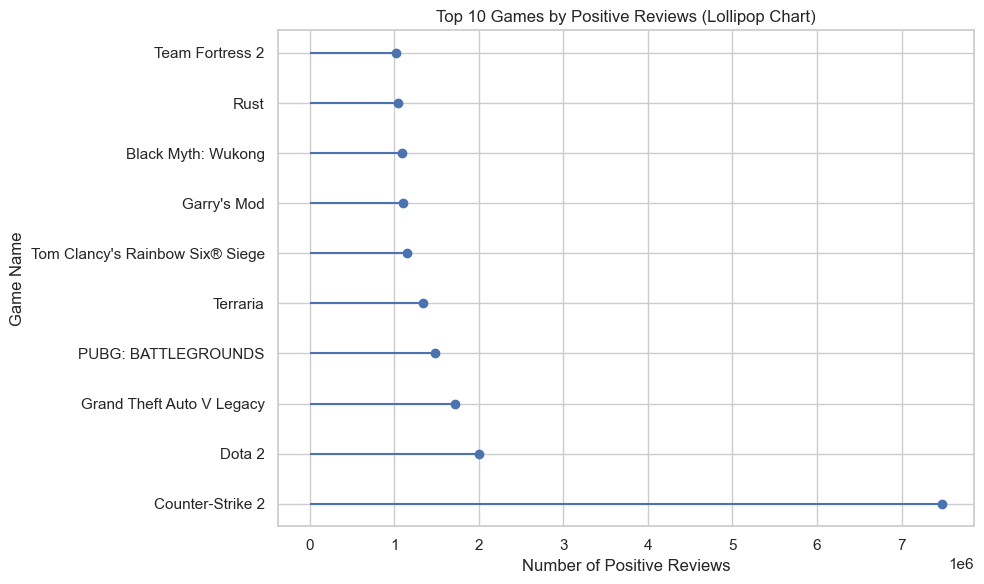

In [ ]:
# Get top 10 games
top_games = df.sort_values(by='positive', ascending=False).head(10)

plt.figure(figsize=(10,6))

# Draw lines
plt.hlines(
    y=top_games['name'],
    xmin=0,
    xmax=top_games['positive']
)

# Draw dots
plt.plot(
    top_games['positive'],
    top_games['name'],
    "o"b
)

plt.title("Top 10 Games by Positive Reviews (Lollipop Chart)")
plt.xlabel("Number of Positive Reviews")
plt.ylabel("Game Name")

plt.tight_layout()
plt.show()

Conclusion:
A small number of games dominate in terms of positive reviews, with a significant gap between the top titles and others. This highlights the competitive nature of the platform where only a few games achieve extreme popularity.

Analysis 32: How does average popularity vary across top genres? (Radial View)

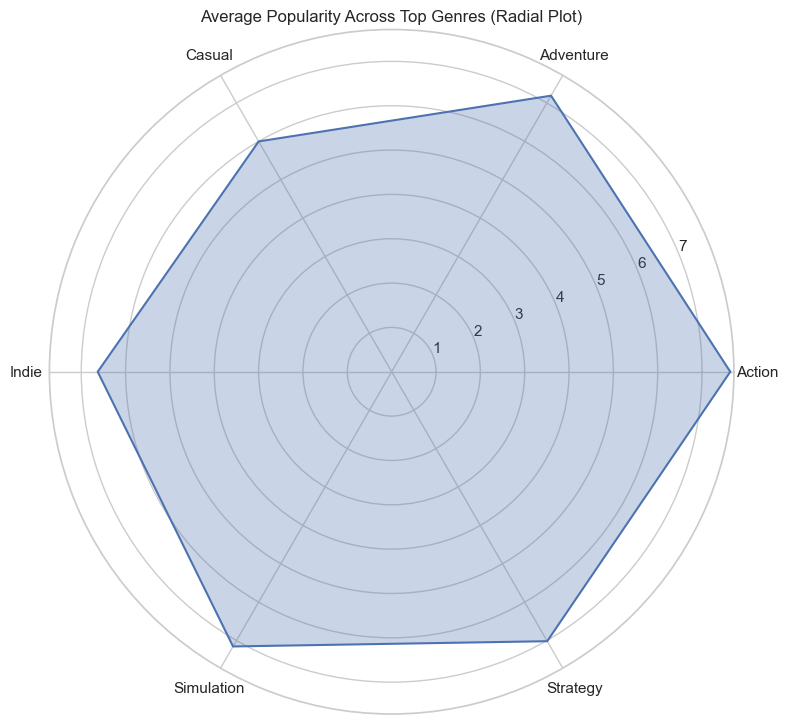

In [ ]:
import numpy as np

# Explode genres
genre_exploded = df.explode('genres')

# Get top 6 genres
top_genres = genre_exploded['genres'].value_counts().head(6).index

# Compute average popularity
genre_avg = genre_exploded[
    genre_exploded['genres'].isin(top_genres)
].groupby('genres')['positive'].mean()

# Normalize (log scale to avoid distortion)
genre_avg = np.log1p(genre_avg)

# Prepare angles
labels = genre_avg.index
values = genre_avg.values

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
values = np.append(values, values[0])
angles = np.append(angles, angles[0])

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

ax.plot(angles, values)
ax.fill(angles, values, alpha=0.3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

plt.title("Average Popularity Across Top Genres (Radial Plot)")

plt.tight_layout()
plt.show()

Conclusion:
The radial plot shows variation in average popularity across genres, with some genres clearly outperforming others. This indicates that player engagement is not evenly distributed and depends strongly on genre preferences.

Analysis 33: Can games be grouped into distinct clusters based on popularity and engagement?

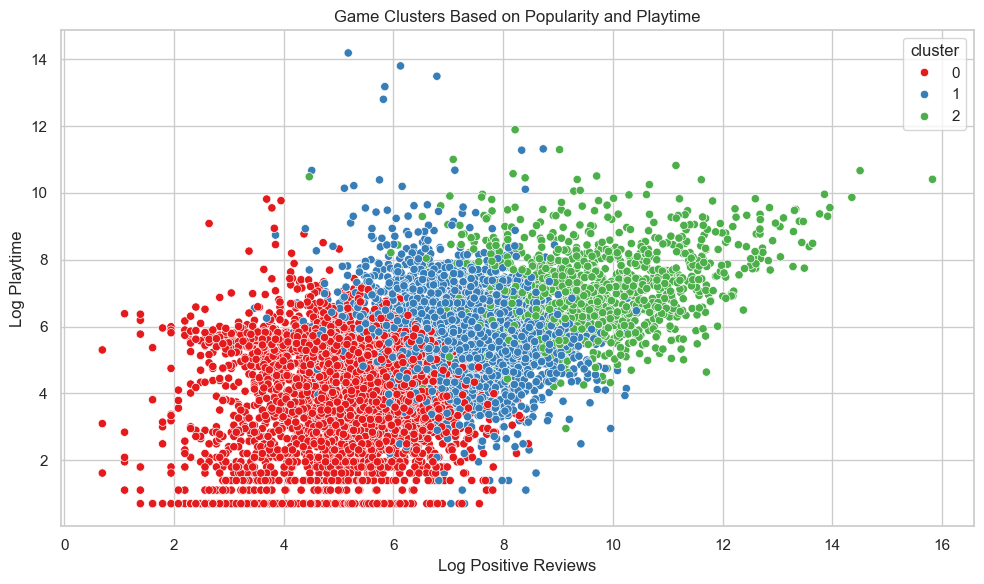

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans

# Select required columns
cluster_df = df[['positive', 'average_playtime_forever', 'price']].copy()

# Clean data
cluster_df = cluster_df[
    (cluster_df['positive'] > 0) &
    (cluster_df['average_playtime_forever'] > 0)
].dropna()

# Log transform (important for skew)
cluster_df['log_positive'] = np.log1p(cluster_df['positive'])
cluster_df['log_playtime'] = np.log1p(cluster_df['average_playtime_forever'])

# Features for clustering
cluster_df['log_ccu'] = np.log1p(df.loc[cluster_df.index, 'peak_ccu'])

X = cluster_df[['log_positive', 'log_playtime', 'log_ccu']]
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['cluster'] = kmeans.fit_predict(X)

# Safe sampling (FIXED)
sample_data = cluster_df.sample(min(10000, len(cluster_df)), random_state=42)

# Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_data,
    x='log_positive',
    y='log_playtime',
    hue='cluster',
    palette='Set1'
)

plt.title("Game Clusters Based on Popularity and Playtime")
plt.xlabel("Log Positive Reviews")
plt.ylabel("Log Playtime")

plt.tight_layout()
plt.show()

Conclusion:
The clustering reveals three distinct engagement segments, but with noticeable overlap, indicating that game success is not driven by a single factor. High-performing games tend to combine strong player activity and sustained engagement rather than excelling in just one metric.

Analysis 34: How do different clusters compare across multiple game metrics?

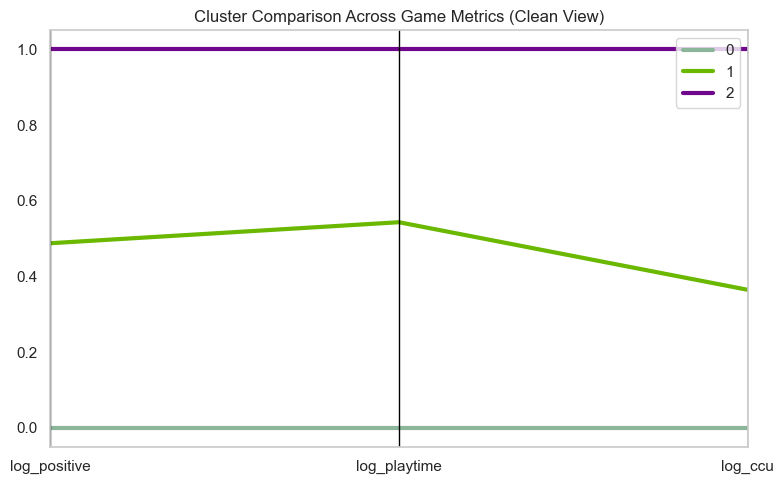

In [ ]:
from pandas.plotting import parallel_coordinates

# Create mean dataframe (with correct columns)
mean_df = cluster_df.groupby('cluster')[[
    'log_positive',
    'log_playtime',
    'log_ccu'
]].mean().reset_index()

# Normalize
for col in ['log_positive', 'log_playtime', 'log_ccu']:
    mean_df[col] = (mean_df[col] - mean_df[col].min()) / (mean_df[col].max() - mean_df[col].min())

plt.figure(figsize=(8,5))

parallel_coordinates(
    mean_df,
    'cluster',
    linewidth=3
)

plt.title("Cluster Comparison Across Game Metrics (Clean View)")

plt.tight_layout()
plt.show()

Conclusion:
The visualization highlights a clear hierarchy among clusters. One cluster consistently dominates across all engagement metrics, while another remains uniformly low, indicating that successful games tend to perform well across multiple dimensions rather than excelling in just one.

Analysis 35: How does popularity distribution vary across different price segments?

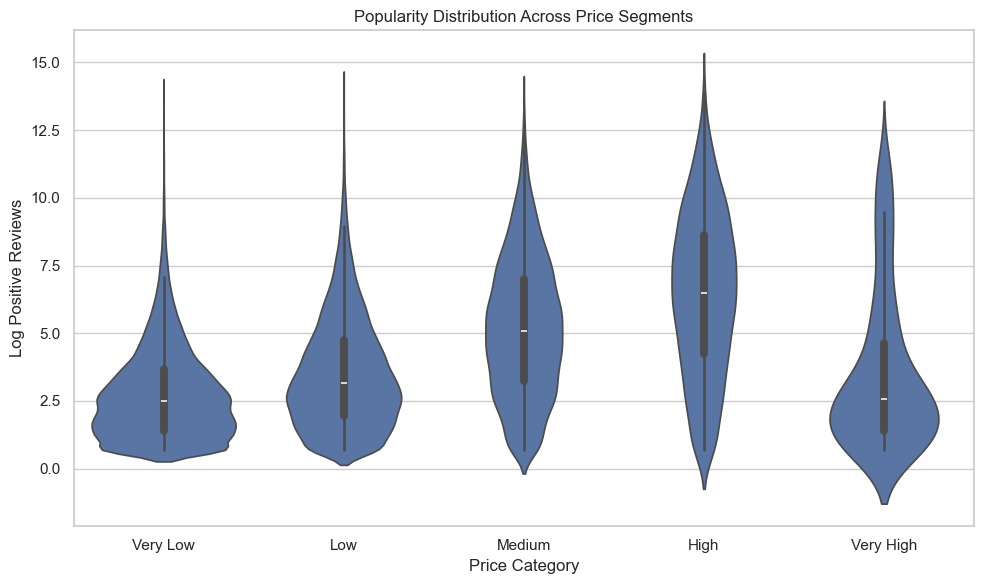

In [ ]:
import numpy as np

# Create price categories (if not already created)
df['price_category'] = pd.cut(
    df['price'],
    bins=[0, 5, 15, 30, 60, 200],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

# Prepare data
violin_df = df[df['positive'] > 0].copy()
violin_df['log_positive'] = np.log1p(violin_df['positive'])

# Plot
plt.figure(figsize=(10,6))

sns.violinplot(
    data=violin_df,
    x='price_category',
    y='log_positive'
)

plt.title("Popularity Distribution Across Price Segments")
plt.xlabel("Price Category")
plt.ylabel("Log Positive Reviews")

plt.tight_layout()
plt.show()

Conclusion:
The distribution of popularity varies significantly across price segments. Lower-priced games show a wider spread with both low and extremely high performers, while higher-priced games tend to have more consistent but less extreme popularity.

Analysis 36: How do price, popularity, and player activity interact?

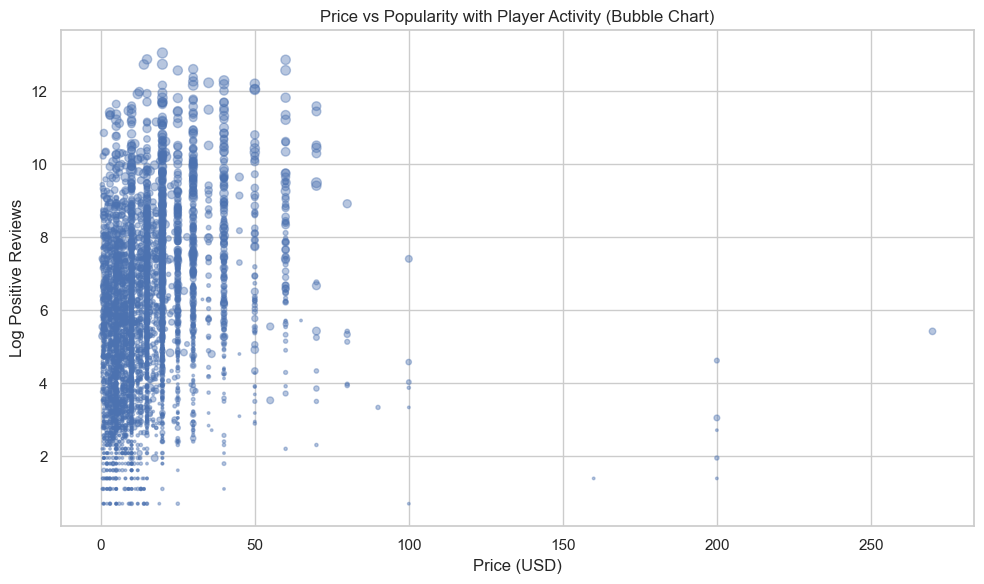

In [ ]:
import numpy as np

# Prepare data
bubble_df = df[
    (df['positive'] > 0) &
    (df['peak_ccu'] > 0) &
    (df['price'] > 0)
].copy()

# Reduce skew
bubble_df = bubble_df[
    (bubble_df['positive'] < 500000) &
    (bubble_df['peak_ccu'] < 500000)
]

# Log transform
bubble_df['log_positive'] = np.log1p(bubble_df['positive'])
bubble_df['log_ccu'] = np.log1p(bubble_df['peak_ccu'])

# Sample for performance
bubble_df = bubble_df.sample(min(5000, len(bubble_df)), random_state=42)

plt.figure(figsize=(10,6))

plt.scatter(
    bubble_df['price'],
    bubble_df['log_positive'],
    s=bubble_df['log_ccu'] * 5,  # bubble size
    alpha=0.4
)

plt.title("Price vs Popularity with Player Activity (Bubble Chart)")
plt.xlabel("Price (USD)")
plt.ylabel("Log Positive Reviews")

plt.tight_layout()
plt.show()

Conclusion:
The bubble chart shows that highly active games with large player bases are mostly concentrated in lower to mid-price ranges. High-priced games rarely achieve both high popularity and high concurrent player activity.

Analysis 37: Which game genres frequently appear together?

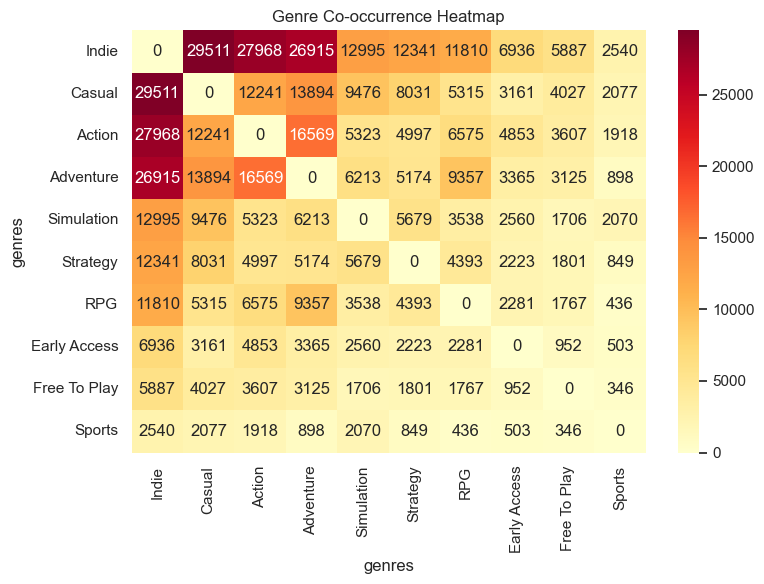

In [ ]:
import numpy as np
from itertools import combinations

# Ensure genres are lists
genre_df = df[df['genres'].notna()].copy()

# Get top genres (limit for clarity)
top_genres = genre_df.explode('genres')['genres'].value_counts().head(10).index

# Create co-occurrence matrix
matrix = pd.DataFrame(0, index=top_genres, columns=top_genres)

for genres in genre_df['genres']:
    if isinstance(genres, list):
        filtered = [g for g in genres if g in top_genres]
        for g1, g2 in combinations(filtered, 2):
            matrix.loc[g1, g2] += 1
            matrix.loc[g2, g1] += 1

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='YlOrRd'
)

plt.title("Genre Co-occurrence Heatmap")

plt.tight_layout()
plt.show()

Conclusion:
The heatmap reveals strong co-occurrence patterns between specific genres, highlighting common combinations such as action-adventure or RPG-strategy. These patterns reflect consistent design trends and player preferences.

Analysis 38: What is the distribution of games across different genres?

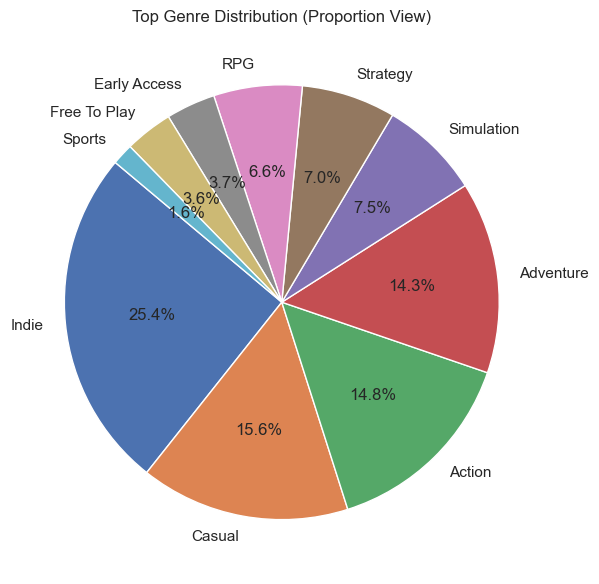

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Flatten genres
all_genres = []
for genres in df['genres']:
    if isinstance(genres, list):
        all_genres.extend(genres)

# Count top 10 genres
genre_counts = Counter(all_genres)
top_genres = dict(genre_counts.most_common(10))

# Prepare data
labels = list(top_genres.keys())
sizes = list(top_genres.values())

plt.figure(figsize=(10,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Top Genre Distribution (Proportion View)")

plt.tight_layout()
plt.show()

Conclusion:
The distribution of genres is highly uneven, with a few genres dominating the platform. This indicates that game development is concentrated around popular genres with proven demand.

Analysis 39: How have top game genres evolved over time?

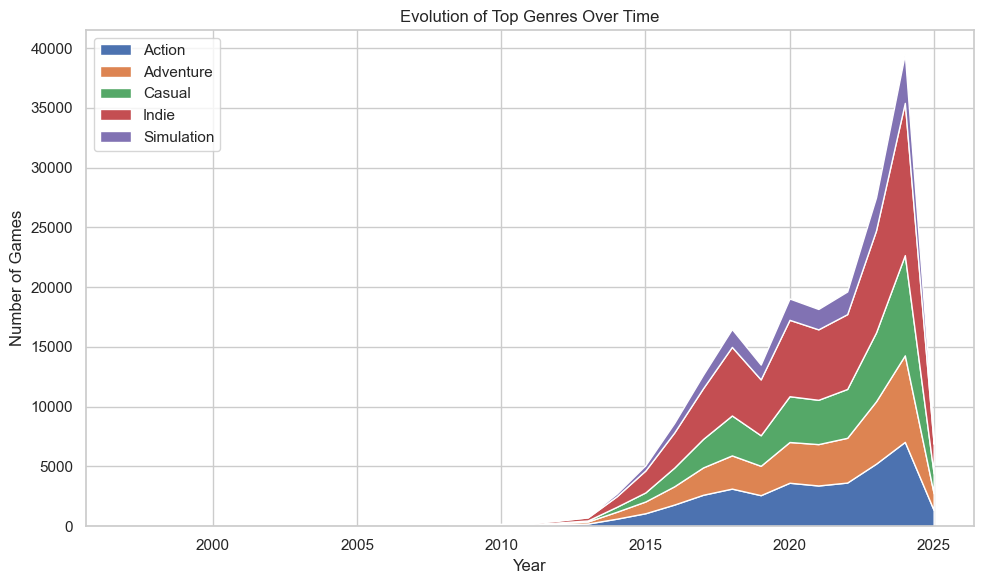

In [ ]:
# Explode genres
genre_year_df = df.explode('genres')

# Get top 5 genres (to avoid clutter)
top_genres = genre_year_df['genres'].value_counts().head(5).index

# Filter only those
genre_year_df = genre_year_df[genre_year_df['genres'].isin(top_genres)]

# Count per year per genre
trend_df = genre_year_df.groupby(['year', 'genres']).size().unstack().fillna(0)

# Plot
plt.figure(figsize=(10,6))

plt.stackplot(
    trend_df.index,
    trend_df.T,
    labels=trend_df.columns
)

plt.title("Evolution of Top Genres Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Games")

plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Conclusion:
The stacked area chart shows that certain genres have consistently dominated over time, while others have experienced growth or decline. This reflects evolving player preferences and changing development trends on the platform.

Analysis 40: What are the key relationships between major game metrics?

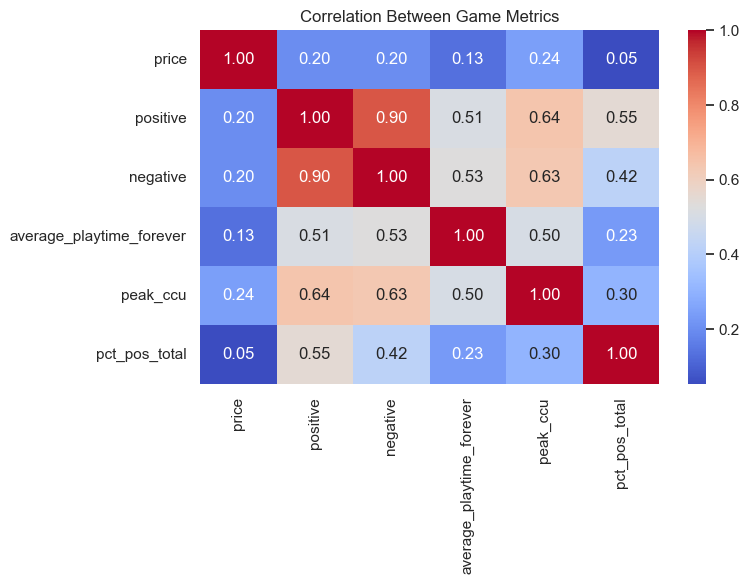

In [ ]:
import numpy as np

# Select important numerical features
corr_df = df[[
    'price',
    'positive',
    'negative',
    'average_playtime_forever',
    'peak_ccu',
    'pct_pos_total'
]].copy()

# Clean
corr_df = corr_df.dropna()

# Log transform skewed columns
corr_df['positive'] = np.log1p(corr_df['positive'])
corr_df['negative'] = np.log1p(corr_df['negative'])
corr_df['peak_ccu'] = np.log1p(corr_df['peak_ccu'])
corr_df['average_playtime_forever'] = np.log1p(corr_df['average_playtime_forever'])

# Correlation matrix
corr = corr_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Between Game Metrics")

plt.tight_layout()
plt.show()

Conclusion:
The correlation analysis highlights strong relationships between player engagement metrics such as positive reviews, concurrent users, and playtime. In contrast, price shows weak correlation with success, indicating that game popularity is driven more by user experience and engagement rather than pricing strategy.